In [ ]:
import pandas as pd

# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/Student_Performance.csv')

# Display the first 5 rows of the DataFrame
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
print("Missing values before preprocessing:\n", df.isnull().sum())

Missing values before preprocessing:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Extracurricular Activities'], drop_first=True)
X = df_encoded.drop('Performance Index', axis=1)
y = df_encoded['Performance Index']

print("Shape of X after one-hot encoding:", X.shape)
print("Columns in X:", X.columns.tolist())

Shape of X after one-hot encoding: (10000, 5)
Columns in X: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities_Yes']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (all except the one-hot encoded one)
numerical_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns in X
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

print("First 5 rows of X after scaling numerical features:")
print(X_scaled.head())


First 5 rows of X after scaling numerical features:
   Hours Studied  Previous Scores  Sleep Hours  \
0       0.775188         1.704176     1.456205   
1      -0.383481         0.723913    -1.492294   
2       1.161410        -1.063626     0.276805   
3       0.002742        -1.005963    -0.902594   
4       0.775188         0.320275     0.866505   

   Sample Question Papers Practiced  Extracurricular Activities_Yes  
0                         -1.249754                            True  
1                         -0.900982                           False  
2                         -0.900982                            True  
3                         -0.900982                            True  
4                          0.145333                           False  


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 5)
Shape of X_test: (2000, 5)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Calculate Mean Squared Error and R-squared score
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Multiple Linear Regression - Mean Squared Error: {mse_lr:.2f}")
print(f"Multiple Linear Regression - R-squared: {r2_lr:.2f}")

Multiple Linear Regression - Mean Squared Error: 4.08
Multiple Linear Regression - R-squared: 0.99


In [ ]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# Use LassoCV to find the optimal alpha
# cv=5 for 5-fold cross-validation
# random_state for reproducibility
lasso_cv = LassoCV(cv=5, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available CPU cores
lasso_cv.fit(X_train, y_train)

# Get the optimal alpha
optimal_alpha_lasso = lasso_cv.alpha_

# Instantiate Lasso model with the optimal alpha
lasso_model = Lasso(alpha=optimal_alpha_lasso, random_state=42)

# Train the Lasso model
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Calculate Mean Squared Error and R-squared score
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - Optimal Alpha: {optimal_alpha_lasso:.4f}")
print(f"Lasso Regression - Mean Squared Error: {mse_lasso:.2f}")
print(f"Lasso Regression - R-squared: {r2_lasso:.2f}")

Lasso Regression - Optimal Alpha: 0.0176
Lasso Regression - Mean Squared Error: 4.09
Lasso Regression - R-squared: 0.99


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

# Use RidgeCV to find the optimal alpha
# cv=5 for 5-fold cross-validation
# alphas=np.logspace(-6, 6, 13) provides a range of alpha values to search
# random_state for reproducibility
ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
ridge_cv.fit(X_train, y_train)

# Get the optimal alpha
optimal_alpha_ridge = ridge_cv.alpha_

# Instantiate Ridge model with the optimal alpha
ridge_model = Ridge(alpha=optimal_alpha_ridge, random_state=42)

# Train the Ridge model
ridge_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Calculate Mean Squared Error and R-squared score
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - Optimal Alpha: {optimal_alpha_ridge:.4f}")
print(f"Ridge Regression - Mean Squared Error: {mse_ridge:.2f}")
print(f"Ridge Regression - R-squared: {r2_ridge:.2f}")

Ridge Regression - Optimal Alpha: 0.1000
Ridge Regression - Mean Squared Error: 4.08
Ridge Regression - R-squared: 0.99


In [ ]:
print("\n--- Model Performance Summary ---")
print(f"Multiple Linear Regression: MSE={mse_lr:.2f}, R2={r2_lr:.2f}")
print(f"Lasso Regression:           MSE={mse_lasso:.2f}, R2={r2_lasso:.2f}")
print(f"Ridge Regression:           MSE={mse_ridge:.2f}, R2={r2_ridge:.2f}")

# Optional: Store results in a dictionary for further analysis/plotting if needed
model_performance = {
    'Linear Regression': {'MSE': mse_lr, 'R2': r2_lr},
    'Lasso Regression': {'MSE': mse_lasso, 'R2': r2_lasso},
    'Ridge Regression': {'MSE': mse_ridge, 'R2': r2_ridge}
}

print("\nDetailed Model Performance:")
for model, metrics in model_performance.items():
    print(f"{model:<20}: MSE={metrics['MSE']:.2f}, R2={metrics['R2']:.2f}")


--- Model Performance Summary ---
Multiple Linear Regression: MSE=4.08, R2=0.99
Lasso Regression:           MSE=4.09, R2=0.99
Ridge Regression:           MSE=4.08, R2=0.99

Detailed Model Performance:
Linear Regression   : MSE=4.08, R2=0.99
Lasso Regression    : MSE=4.09, R2=0.99
Ridge Regression    : MSE=4.08, R2=0.99


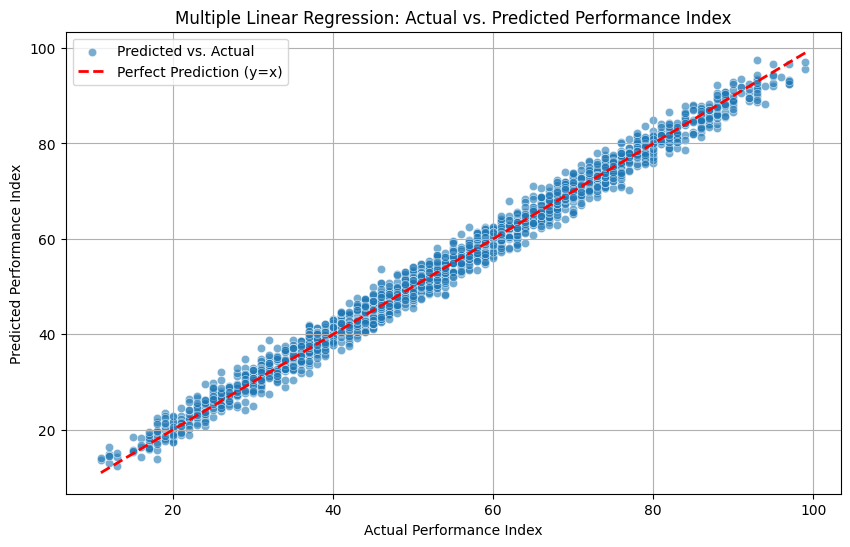

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for Multiple Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, label='Predicted vs. Actual')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--r', linewidth=2, label='Perfect Prediction (y=x)')

# Add labels and title
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Multiple Linear Regression: Actual vs. Predicted Performance Index')
plt.legend()
plt.grid(True)
plt.show()


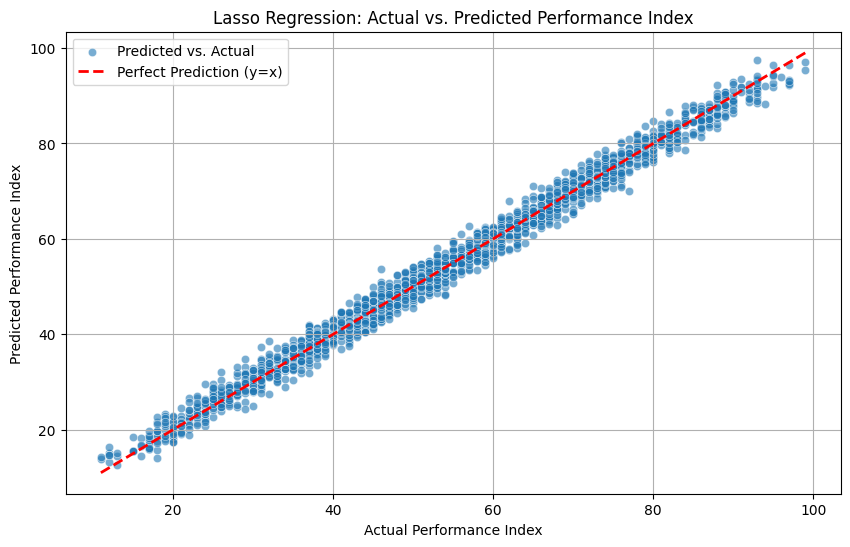

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for Lasso Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6, label='Predicted vs. Actual')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--r', linewidth=2, label='Perfect Prediction (y=x)')

# Add labels and title
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Lasso Regression: Actual vs. Predicted Performance Index')
plt.legend()
plt.grid(True)
plt.show()

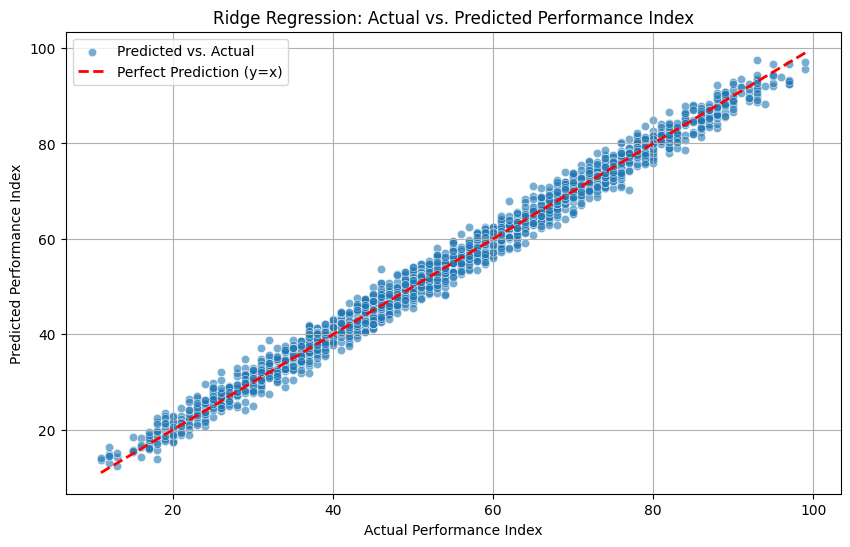

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for Ridge Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6, label='Predicted vs. Actual')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         '--r', linewidth=2, label='Perfect Prediction (y=x)')

# Add labels and title
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Ridge Regression: Actual vs. Predicted Performance Index')
plt.legend()
plt.grid(True)
plt.show()